# Prime Video + Netflix EDA Notebook Guide



**FOCUS OF THE EDA**

This notebook focuses on the Netflix and Prime Video public datasets. Since both platforms represent long-form streaming behavior, they are inspected together while still keeping their public source files separate.

The goal is to inspect basic structure, daily viewing patterns, title quality, platform differences, and a combined `long_form_streaming` daily view for later cross-platform analysis. Below much more detailed explanation



## 1. Notebook Setup And Data Loading

This section prepares the notebook environment and loads the public Netflix and Prime Video datasets.

- Imports the required libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, and `Path`.
- Sets a readable seaborn plotting theme using a colorblind-friendly palette.
- Defines paths so the notebook can run from either the repo root or the `EDA/` folder.
- Loads:
  - `data_github/netflix_public/netflix_viewing_public.csv`
  - `data_github/prime_video_public/prime_video_watch_history_public.csv`
- Creates the image output folder:
  - `EDA/prime_netflix_images`

Related cells: `1-2`

## 2. Basic Data Inspection

This section checks what the datasets look like before any visualization.

- Prints sample rows from both Netflix and Prime Video.
- Prints dataset shapes.
- Compares shared columns and platform-specific columns.
- Prints dataframe info for both datasets.
- Prints missing-value counts for both datasets.

The goal is to understand whether Netflix and Prime Video can be compared directly and which fields are unique to each platform.

Related cells: `3-6`

## 3. Date Preparation

This section prepares the common date field used throughout the analysis.

- Converts `fine_date` into datetime format for both datasets.
- Prints the date range of Netflix.
- Prints the date range of Prime Video.

This is important because all later daily, monthly, and combined long-form streaming analysis depends on `fine_date`.

Related cells: `7-8`

## 4. Individual Daily Viewing Counts

This section creates separate daily viewing tables for Netflix and Prime Video.

- Groups Netflix rows by `fine_date` to create `netflix_daily_count`.
- Groups Prime Video rows by `fine_date` to create `prime_daily_count`.
- Plots daily viewing counts on active days for both platforms.
- Plots the distribution of active-day viewing counts for both platforms.

Plot outputs:
- `daily_viewing_count_netflix_vs_prime.png`
- `daily_count_distribution_active_days.png`

Related cells: `9-13`

## 5. Netflix Title Quality Check

This section checks a known Netflix title issue before using titles in top-title plots.

- Creates a mask for Netflix titles that are blank or start with a colon, such as `: 5. Bölüm`.
- Prints the number of missing or malformed Netflix title rows.
- Prints examples of those rows.
- Builds a title-quality summary table.
- Plots usable vs missing/malformed Netflix title counts.

These malformed title rows are still real viewing records, so they stay in daily count analysis. They are excluded only from title-ranking plots.

Plot output:
- `netflix_title_quality_split.png`

Related cells: `14-17`

## 6. Top Title / Series Analysis

This section prepares and plots the most repeated titles or series for each platform.

For Netflix:
- Keeps only usable title rows for title-ranking analysis.
- Creates a `title_group` by taking the part before the first colon.
- This groups series episodes under the same show name while keeping movies mostly unchanged.

For Prime Video:
- Uses structured fields first instead of only splitting the public `title`.
- Uses `series_title` where available.
- Uses `movie_title` when `series_title` is missing.
- Falls back to the public `title` when needed.

Plot outputs:
- `top_15_netflix_title_groups.png`
- `top_15_prime_video_title_groups.png`

Related cells: `18-21`

## 7. Combined Long-Form Streaming Table

This section combines Netflix and Prime Video at the daily level for EDA only.

- Finds the common date range between Netflix and Prime Video.
- Creates a complete daily date table for that shared range.
- Merges Netflix daily counts and Prime Video daily counts.
- Fills missing platform rows with zero, meaning no watch record on that platform for that date.
- Creates:
  - `long_form_streaming_daily_count = netflix_daily_count + prime_daily_count`
  - `long_form_streaming_active_day`
- Prints descriptive statistics for Netflix, Prime Video, and combined long-form streaming.
- Prints active-day counts.
- Builds total platform counts inside the common date range.

Netflix and Prime Video remain separate public datasets. They are combined here only as an EDA layer for long-form streaming behavior.

Plot output:
- `total_long_form_count_by_platform_common_range.png`

Related cells: `22-26`

## 8. Combined Daily Long-Form Streaming Visualizations

This section visualizes the combined daily long-form streaming behavior.

- Plots total Netflix + Prime Video daily viewing count.
- Plots Netflix and Prime Video daily counts separately after zero-filling missing dates.
- Plots the distribution of combined long-form daily counts, including zero days.

Plot outputs:
- `combined_long_form_streaming_daily_count.png`
- `long_form_streaming_by_platform.png`
- `combined_long_form_distribution.png`

Related cells: `27-29`

## 9. Monthly Long-Form Streaming Trends

This section aggregates long-form streaming to the monthly level to reduce daily noise.

- Creates monthly totals for:
  - Netflix daily count
  - Prime Video daily count
  - Combined long-form daily count
- Plots monthly Netflix vs Prime Video counts.
- Plots monthly combined Netflix + Prime Video count.
- Annotates the peak month in the combined monthly plot.

Plot outputs:
- `monthly_long_form_count_by_platform.png`
- `monthly_combined_long_form_count.png`

Related cells: `30-32`

## 10. Richer Daily Pattern Checks

This section adds more varied plot types similar to the course recitation examples.

- Creates weekday labels from `fine_date`.
- Plots combined long-form streaming daily count by weekday using a boxplot.
- Plots daily Netflix vs Prime Video viewing counts as a scatter plot.
- Counts Prime Video record types.
- Plots Prime Video record type split.

The Prime Video record type plot is only for Prime Video because Netflix does not have a `record_type` column.

Plot outputs:
- `long_form_daily_count_by_weekday_boxplot.png`
- `netflix_vs_prime_daily_scatter.png`
- `prime_video_record_type_split.png`

Related cells: `33-37`

## 11. Overview Panel And Final Notes

This section creates one compact multi-panel summary figure and closes the notebook with interpretation notes.

The 2x2 overview panel includes:
- Daily long-form count over time
- Distribution of daily long-form count
- Netflix vs Prime Video daily scatter
- Total long-form count by platform

Final notes emphasize:
- The combined daily table is useful for later cross-platform EDA.
- Netflix and Prime Video remain separate public datasets.
- `long_form_streaming_daily_count` and `long_form_streaming_active_day` are analysis-layer variables.
- Malformed Netflix titles are excluded only from title-ranking plots, not from daily activity counts.

Plot output:
- `prime_netflix_eda_overview_panel.png`

Related cells: `38-39`


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Course recitation style: readable grid, colorblind palette, clear labels.
sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")

# Path handling that works from either the repo root or the EDA folder.
if Path("data_github/prime_video_public/prime_video_watch_history_public.csv").exists():
    prime_data_path = Path("data_github/prime_video_public/prime_video_watch_history_public.csv")
    netflix_data_path = Path("data_github/netflix_public/netflix_viewing_public.csv")
    prime_netflix_image_dir = Path("EDA/prime_netflix_images")
else:
    prime_data_path = Path("../data_github/prime_video_public/prime_video_watch_history_public.csv")
    netflix_data_path = Path("../data_github/netflix_public/netflix_viewing_public.csv")
    prime_netflix_image_dir = Path("prime_netflix_images")

prime_netflix_image_dir.mkdir(parents=True, exist_ok=True)

# Loading the public Netflix and Prime Video datasets.
prime_data = pd.read_csv(prime_data_path)
netflix_data = pd.read_csv(netflix_data_path)


****CHECKING THE STATISTICAL AND GENERAL INFO OF THE DATA BEFORE VISUALIZING ANYTHING****

In [33]:
print("Netflix Data Sample:")
print(netflix_data.head())

print("\nPrime Video Data Sample:")
print(prime_data.head())


Netflix Data Sample:
  fine_platform              fine_table       fine_record_id  fine_account  \
0       netflix  netflix_viewing_public  netflix_view_000001           NaN   
1       netflix  netflix_viewing_public  netflix_view_000002           NaN   
2       netflix  netflix_viewing_public  netflix_view_000003           NaN   
3       netflix  netflix_viewing_public  netflix_view_000004           NaN   
4       netflix  netflix_viewing_public  netflix_view_000005           NaN   

  fine_source_file fine_time_start fine_time_end fine_time_granularity  \
0    source_000001      2026-03-10    2026-03-10                  date   
1    source_000001      2026-02-07    2026-02-07                  date   
2    source_000001      2026-01-27    2026-01-27                  date   
3    source_000001      2026-01-20    2026-01-20                  date   
4    source_000001      2026-01-20    2026-01-20                  date   

    fine_date                                              title 

In [34]:
print("Netflix shape:")
print(netflix_data.shape)

print("\nPrime Video shape:")
print(prime_data.shape)

print("\nCommon columns between the two datasets:")
common_columns = set(prime_data.columns).intersection(set(netflix_data.columns))
print(sorted(common_columns))

print("\nColumns that differ between the two datasets:")
print(sorted(set(prime_data.columns).symmetric_difference(set(netflix_data.columns))))


Netflix shape:
(2493, 11)

Prime Video shape:
(719, 17)

Common columns between the two datasets:
['fine_account', 'fine_date', 'fine_platform', 'fine_record_id', 'fine_source_file', 'fine_table', 'fine_time_end', 'fine_time_granularity', 'fine_time_start', 'title', 'title_missing']

Columns that differ between the two datasets:
['episode_number', 'episode_title', 'movie_title', 'record_type', 'season_number', 'series_title']


In [35]:
# Looking into their main information and missing values.
print("Prime Video Data Info:")
prime_data.info()

print("\nPrime Video missing values:")
print(prime_data.isna().sum())

print("\nNetflix Data Info:")
netflix_data.info()

print("\nNetflix missing values:")
print(netflix_data.isna().sum())


Prime Video Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 719 entries, 0 to 718
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fine_platform          719 non-null    object 
 1   fine_table             719 non-null    object 
 2   fine_record_id         719 non-null    object 
 3   fine_account           0 non-null      float64
 4   fine_source_file       719 non-null    object 
 5   fine_time_start        719 non-null    object 
 6   fine_time_end          719 non-null    object 
 7   fine_time_granularity  719 non-null    object 
 8   fine_date              719 non-null    object 
 9   record_type            719 non-null    object 
 10  title                  716 non-null    object 
 11  series_title           667 non-null    object 
 12  season_number          613 non-null    float64
 13  episode_number         667 non-null    float64
 14  episode_title          667 non-null

**DOING DATA TRANSFORMATIONS**

**MAKING SURE DATE/TIME WORKS SINCE IT IS THE COMMON COLUMN THAT WILL BE USED IN THE SYSTEM**

In [36]:
# Making sure the dates are usable as dates.
netflix_data["fine_date"] = pd.to_datetime(netflix_data["fine_date"])
prime_data["fine_date"] = pd.to_datetime(prime_data["fine_date"])

print("Netflix date range:")
print(netflix_data["fine_date"].min(), "to", netflix_data["fine_date"].max())

print("\nPrime Video date range:")
print(prime_data["fine_date"].min(), "to", prime_data["fine_date"].max())


Netflix date range:
2020-02-25 00:00:00 to 2026-03-10 00:00:00

Prime Video date range:
2022-03-30 00:00:00 to 2026-03-19 00:00:00


**NETFLIX AND PRIME GRURPINGS TO MAKE SURE THEY WORK AS A WHOLE ONE DATASET AS IF THEY REPRESENT THE STREMING PLATFORMS**

In [37]:
# Netflix daily viewing count.
netflix_daily_count = (
    netflix_data
    .groupby("fine_date")
    .size()
    .reset_index(name="netflix_daily_count")
)

print("Netflix daily count sample:")
print(netflix_daily_count.head())


Netflix daily count sample:
   fine_date  netflix_daily_count
0 2020-02-25                    1
1 2020-03-20                    1
2 2020-04-15                    1
3 2020-04-18                    1
4 2020-04-19                    8


In [38]:
# Prime Video daily viewing count.
prime_daily_count = (
    prime_data
    .groupby("fine_date")
    .size()
    .reset_index(name="prime_daily_count")
)

print("Prime Video daily count sample:")
print(prime_daily_count.head())


Prime Video daily count sample:
   fine_date  prime_daily_count
0 2022-03-30                  2
1 2022-04-03                  3
2 2022-04-13                 14
3 2022-04-14                  1
4 2022-04-30                  1


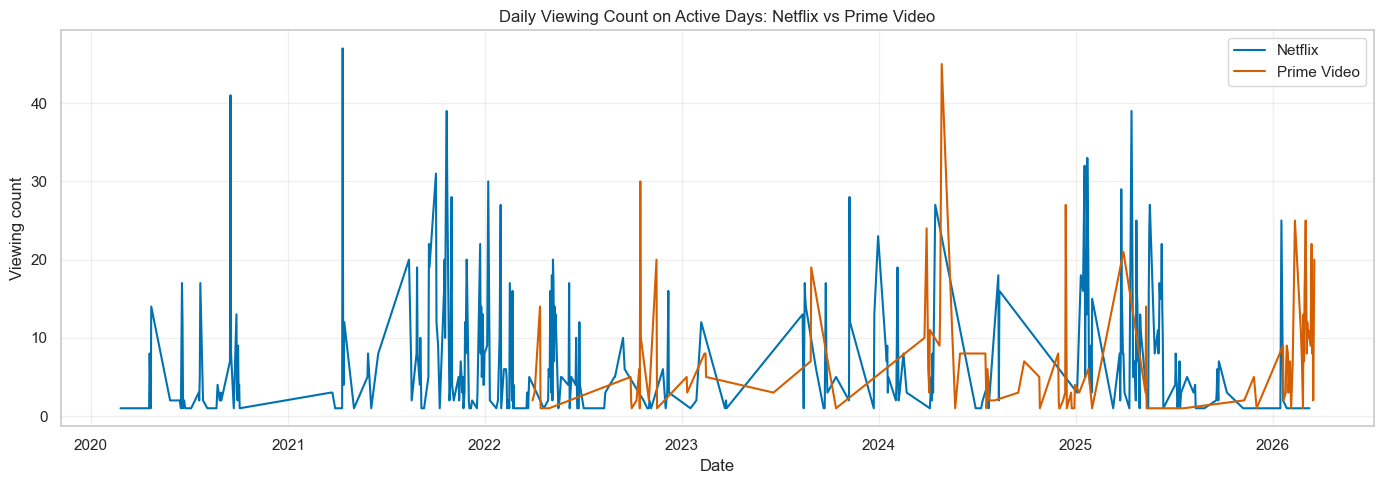

In [39]:
# Plotting daily counts on active days only.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(netflix_daily_count["fine_date"], netflix_daily_count["netflix_daily_count"], label="Netflix", color="#0072B2")
ax.plot(prime_daily_count["fine_date"], prime_daily_count["prime_daily_count"], label="Prime Video", color="#D55E00")

ax.set_title("Daily Viewing Count on Active Days: Netflix vs Prime Video")
ax.set_xlabel("Date")
ax.set_ylabel("Viewing count")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "daily_viewing_count_netflix_vs_prime.png", dpi=300)
plt.show()


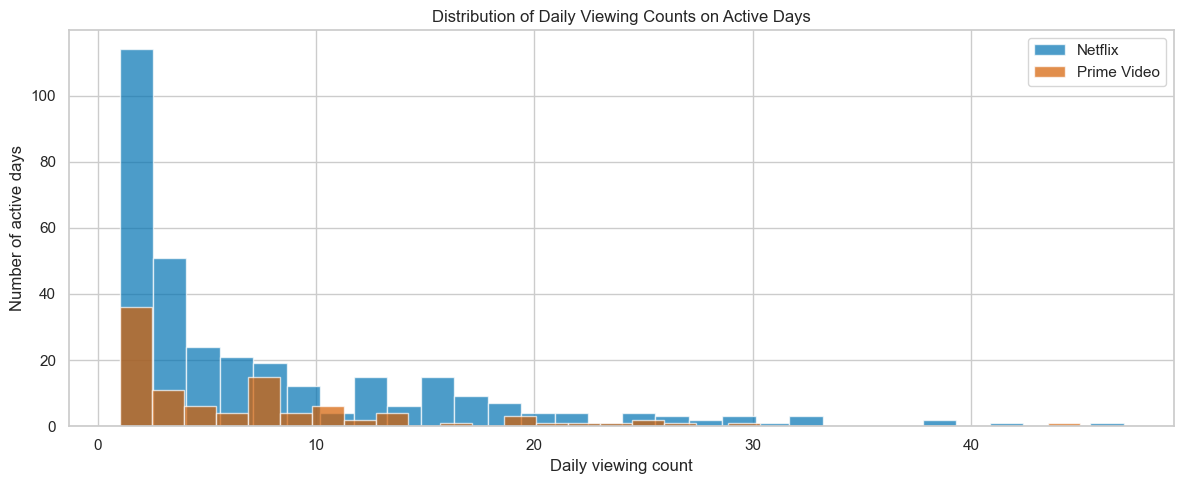

In [40]:
# Distribution of daily counts on active days.
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(netflix_daily_count["netflix_daily_count"], bins=30, alpha=0.7, label="Netflix", color="#0072B2", edgecolor="white")
ax.hist(prime_daily_count["prime_daily_count"], bins=30, alpha=0.7, label="Prime Video", color="#D55E00", edgecolor="white")

ax.set_title("Distribution of Daily Viewing Counts on Active Days")
ax.set_xlabel("Daily viewing count")
ax.set_ylabel("Number of active days")
ax.legend()
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "daily_count_distribution_active_days.png", dpi=300)
plt.show()


**Title Checks**

Netflix has some titles that are blank or start with a colon in the original export, such as `: 5. Bölüm`. These rows are still real viewing records, but they should not be used directly for top-title plots.


In [41]:
# Cleaning Netflix titles only for EDA, not changing the source dataset.
netflix_title_text = netflix_data["title"].fillna("").astype(str).str.strip()
netflix_bad_title_mask = netflix_title_text.eq("") | netflix_title_text.str.startswith(":")

print("Netflix rows with missing or malformed titles:")
print(netflix_bad_title_mask.sum())

print("\nExamples:")
print(netflix_data.loc[netflix_bad_title_mask, ["fine_date", "title"]].head(15))


Netflix rows with missing or malformed titles:
66

Examples:
      fine_date        title
1287 2022-05-23          NaN
1450 2022-04-20          NaN
1464 2022-02-24   : 5. Bölüm
1465 2022-02-23   : 4. Bölüm
1466 2022-02-23   : 3. Bölüm
1467 2022-02-23   : 2. Bölüm
1468 2022-02-23   : 1. Bölüm
1526 2022-01-31   : 6. Bölüm
1618 2021-12-30   : 5. Bölüm
1620 2021-12-29   : 4. Bölüm
1621 2021-12-29   : 3. Bölüm
1622 2021-12-29   : 2. Bölüm
1623 2021-12-29   : 1. Bölüm
1624 2021-12-28  : 13. Bölüm
1625 2021-12-28  : 12. Bölüm


In [42]:
# Netflix title quality split.
netflix_title_quality = pd.DataFrame({
    "title_type": ["usable title", "missing or malformed title"],
    "watch_count": [int((~netflix_bad_title_mask).sum()), int(netflix_bad_title_mask.sum())]
})

print("Netflix title quality counts:")
print(netflix_title_quality)


Netflix title quality counts:
                   title_type  watch_count
0                usable title         2427
1  missing or malformed title           66


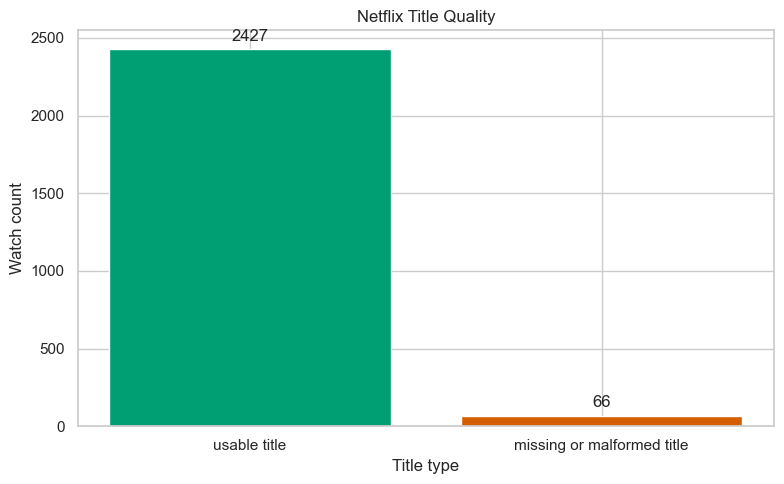

In [43]:
# Plotting Netflix title quality.
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(netflix_title_quality["title_type"], netflix_title_quality["watch_count"], color=["#009E73", "#D55E00"])

ax.set_title("Netflix Title Quality")
ax.set_xlabel("Title type")
ax.set_ylabel("Watch count")
ax.bar_label(bars, padding=4)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "netflix_title_quality_split.png", dpi=300)
plt.show()


In [44]:
# Keeping only usable Netflix titles for top-title analysis.
netflix_titles_for_eda = netflix_data.loc[~netflix_bad_title_mask].copy()

# For series, take the part before the first colon as the show name.
# For movies, this keeps the full movie title.
netflix_titles_for_eda["title_group"] = (
    netflix_titles_for_eda["title"]
    .astype(str)
    .str.strip()
    .str.split(":", n=1)
    .str[0]
    .str.strip()
)

netflix_top_titles = (
    netflix_titles_for_eda["title_group"]
    .value_counts()
    .head(15)
    .sort_values()
)

print("Top Netflix title groups:")
print(netflix_top_titles)


Top Netflix title groups:
title_group
Shadowhunters             55
Ejderhalar Prensi         63
The Walking Dead          64
Avatar                    64
Merlin                    65
Modern Family             67
Vikingler                 71
Lucifer                   76
Gossip Girl               92
Young Sheldon             95
Suits                     97
The Seven Deadly Sins    105
Brooklyn Nine-Nine       127
Friends                  197
How I Met Your Mother    208
Name: count, dtype: int64


In [45]:
# Prime Video title grouping.
# Prime Video has structured series/movie fields, so I use those first instead of splitting only the public title string.
prime_title_text = prime_data["title"].fillna("").astype(str).str.strip()
prime_bad_title_mask = prime_title_text.eq("") | prime_title_text.str.lower().eq("nan")

prime_titles_for_eda = prime_data.loc[~prime_bad_title_mask].copy()
prime_titles_for_eda["title_group"] = prime_titles_for_eda["series_title"].fillna("").astype(str).str.strip()

missing_group = prime_titles_for_eda["title_group"].eq("") | prime_titles_for_eda["title_group"].str.lower().eq("nan")
prime_titles_for_eda.loc[missing_group, "title_group"] = (
    prime_titles_for_eda.loc[missing_group, "movie_title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

missing_group = prime_titles_for_eda["title_group"].eq("") | prime_titles_for_eda["title_group"].str.lower().eq("nan")
prime_titles_for_eda.loc[missing_group, "title_group"] = (
    prime_titles_for_eda.loc[missing_group, "title"]
    .astype(str)
    .str.strip()
)

prime_top_titles = (
    prime_titles_for_eda["title_group"]
    .value_counts()
    .head(15)
    .sort_values()
)

print("Prime Video rows with missing titles:")
print(prime_bad_title_mask.sum())

print("\nTop Prime Video title groups:")
print(prime_top_titles)


Prime Video rows with missing titles:
3

Top Prime Video title groups:
title_group
Friends                                         10
Yüzüklerin Efendisi: Güç Yüzükleri              10
Fallout                                         10
Under a Bad Sign The Complete Second Season     11
Gizli Seviye                                    11
Kung Fu Panda: The Paws of Destiny              13
The Vampire Diaries                             17
Reacher                                         20
The Big Bang Theory                             24
The Boys                                        25
EŞREF RÜYA                                      29
Zaman Çarkı                                     58
Two and a Half Men                              73
Game of Thrones                                 78
Supernatural                                   218
Name: count, dtype: int64


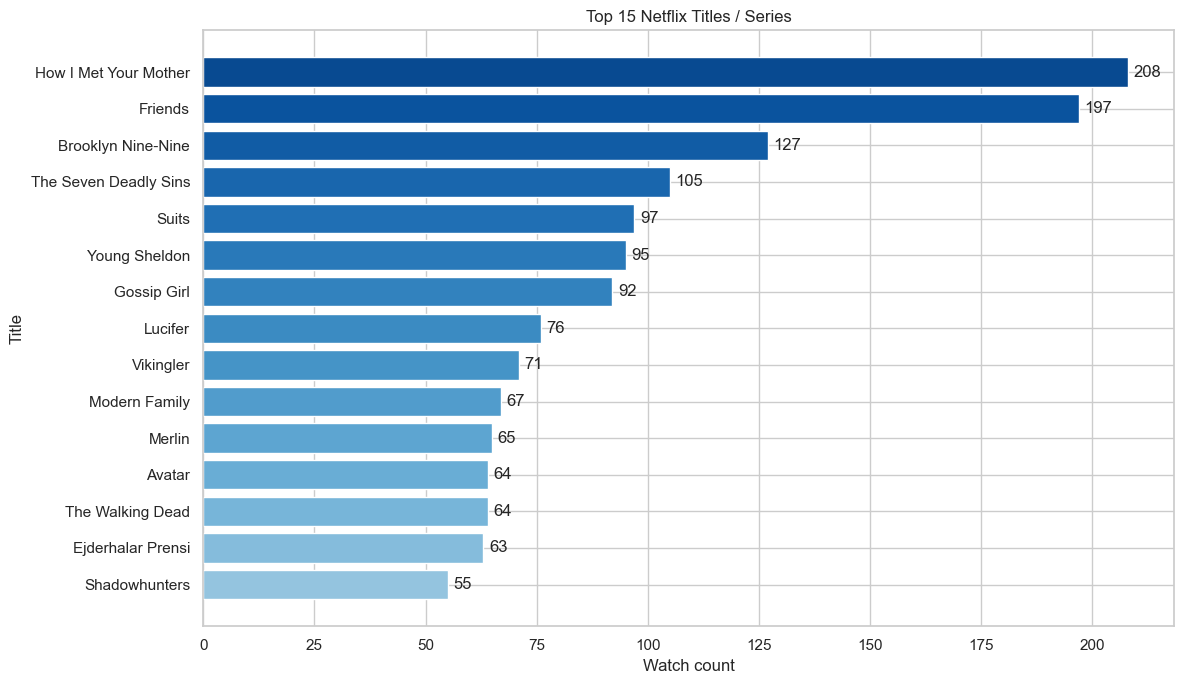

In [46]:
# Plotting top Netflix title groups.
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(netflix_top_titles.index, netflix_top_titles.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(netflix_top_titles))))

ax.set_title("Top 15 Netflix Titles / Series")
ax.set_xlabel("Watch count")
ax.set_ylabel("Title")
ax.bar_label(bars, padding=4)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "top_15_netflix_title_groups.png", dpi=300)
plt.show()


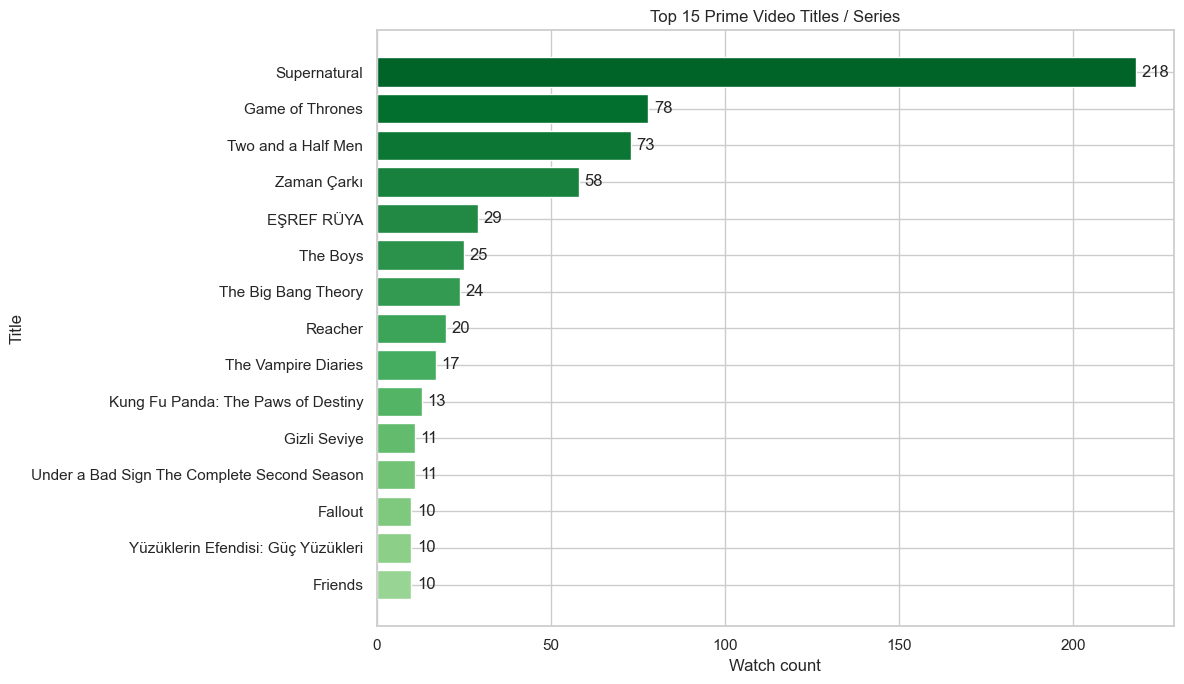

In [47]:
# Plotting top Prime Video title groups.
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(prime_top_titles.index, prime_top_titles.values, color=plt.cm.Greens(np.linspace(0.4, 0.9, len(prime_top_titles))))

ax.set_title("Top 15 Prime Video Titles / Series")
ax.set_xlabel("Watch count")
ax.set_ylabel("Title")
ax.bar_label(bars, padding=4)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "top_15_prime_video_title_groups.png", dpi=300)
plt.show()


**Combined Long-Form Streaming EDA**

Netflix and Prime Video stay separate in public data, but for EDA they can be combined by date as long-form streaming.


In [48]:
# I use the common date range so the two platforms are compared inside the same period.
start_date = max(netflix_data["fine_date"].min(), prime_data["fine_date"].min())
end_date = min(netflix_data["fine_date"].max(), prime_data["fine_date"].max())

all_dates = pd.DataFrame({
    "fine_date": pd.date_range(start=start_date, end=end_date, freq="D")
})

long_form_daily = (
    all_dates
    .merge(netflix_daily_count, on="fine_date", how="left")
    .merge(prime_daily_count, on="fine_date", how="left")
)

# Dates without rows mean there was no watch record on that platform.
long_form_daily["netflix_daily_count"] = long_form_daily["netflix_daily_count"].fillna(0).astype(int)
long_form_daily["prime_daily_count"] = long_form_daily["prime_daily_count"].fillna(0).astype(int)

long_form_daily["long_form_streaming_daily_count"] = (
    long_form_daily["netflix_daily_count"] + long_form_daily["prime_daily_count"]
)

long_form_daily["long_form_streaming_active_day"] = long_form_daily["long_form_streaming_daily_count"] > 0

print("Combined long-form streaming sample:")
print(long_form_daily.head())


Combined long-form streaming sample:
   fine_date  netflix_daily_count  prime_daily_count  \
0 2022-03-30                    0                  2   
1 2022-03-31                    0                  0   
2 2022-04-01                    0                  0   
3 2022-04-02                    0                  0   
4 2022-04-03                    0                  3   

   long_form_streaming_daily_count  long_form_streaming_active_day  
0                                2                            True  
1                                0                           False  
2                                0                           False  
3                                0                           False  
4                                3                            True  


In [49]:
# Basic combined summary.
print("Long-form streaming summary:")
print(long_form_daily[[
    "netflix_daily_count",
    "prime_daily_count",
    "long_form_streaming_daily_count"
]].describe())

print("\nLong-form streaming active day counts:")
print(long_form_daily["long_form_streaming_active_day"].value_counts())


Long-form streaming summary:
       netflix_daily_count  prime_daily_count  long_form_streaming_daily_count
count          1442.000000        1442.000000                      1442.000000
mean              1.006241           0.447989                         1.454230
std               3.787644           2.591102                         4.547649
min               0.000000           0.000000                         0.000000
25%               0.000000           0.000000                         0.000000
50%               0.000000           0.000000                         0.000000
75%               0.000000           0.000000                         0.000000
max              39.000000          45.000000                        45.000000

Long-form streaming active day counts:
long_form_streaming_active_day
False    1174
True      268
Name: count, dtype: int64


In [50]:
# Platform totals in the common date range.
long_form_totals = pd.DataFrame({
    "platform": ["Netflix", "Prime Video"],
    "watch_count": [
        long_form_daily["netflix_daily_count"].sum(),
        long_form_daily["prime_daily_count"].sum()
    ]
})

print("Long-form platform totals in the common date range:")
print(long_form_totals)


Long-form platform totals in the common date range:
      platform  watch_count
0      Netflix         1451
1  Prime Video          646


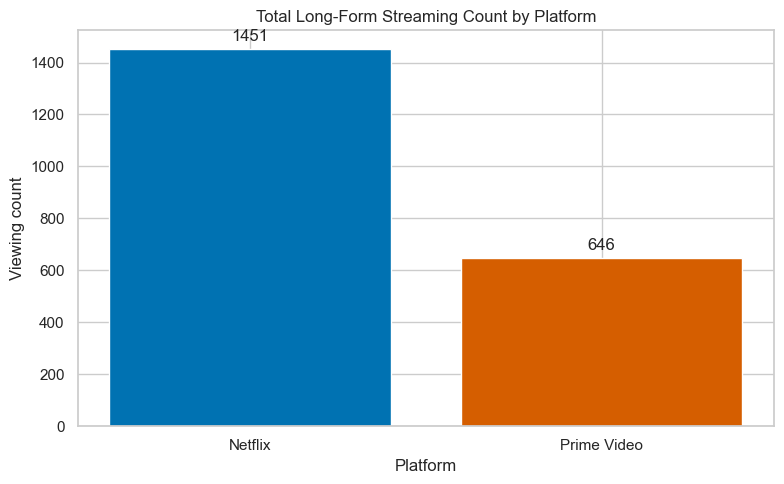

In [51]:
# Plotting total viewing count by platform in the common date range.
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(long_form_totals["platform"], long_form_totals["watch_count"], color=["#0072B2", "#D55E00"])

ax.set_title("Total Long-Form Streaming Count by Platform")
ax.set_xlabel("Platform")
ax.set_ylabel("Viewing count")
ax.bar_label(bars, padding=4)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "total_long_form_count_by_platform_common_range.png", dpi=300)
plt.show()


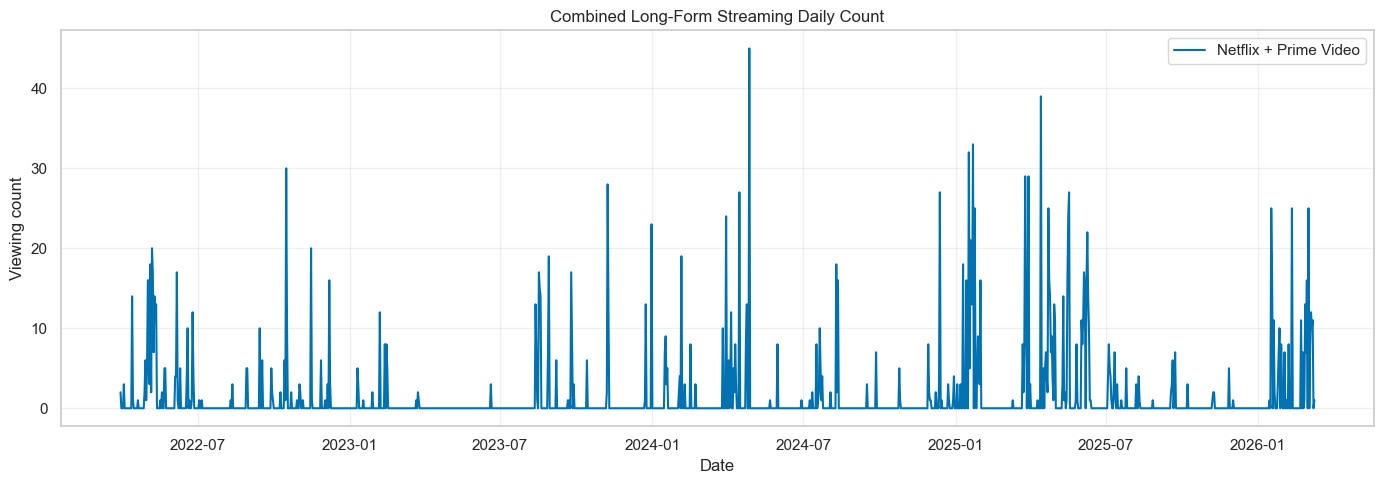

In [52]:
# Plot combined long-form streaming daily count.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    long_form_daily["fine_date"],
    long_form_daily["long_form_streaming_daily_count"],
    color="#0072B2",
    label="Netflix + Prime Video"
)

ax.set_title("Combined Long-Form Streaming Daily Count")
ax.set_xlabel("Date")
ax.set_ylabel("Viewing count")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "combined_long_form_streaming_daily_count.png", dpi=300)
plt.show()


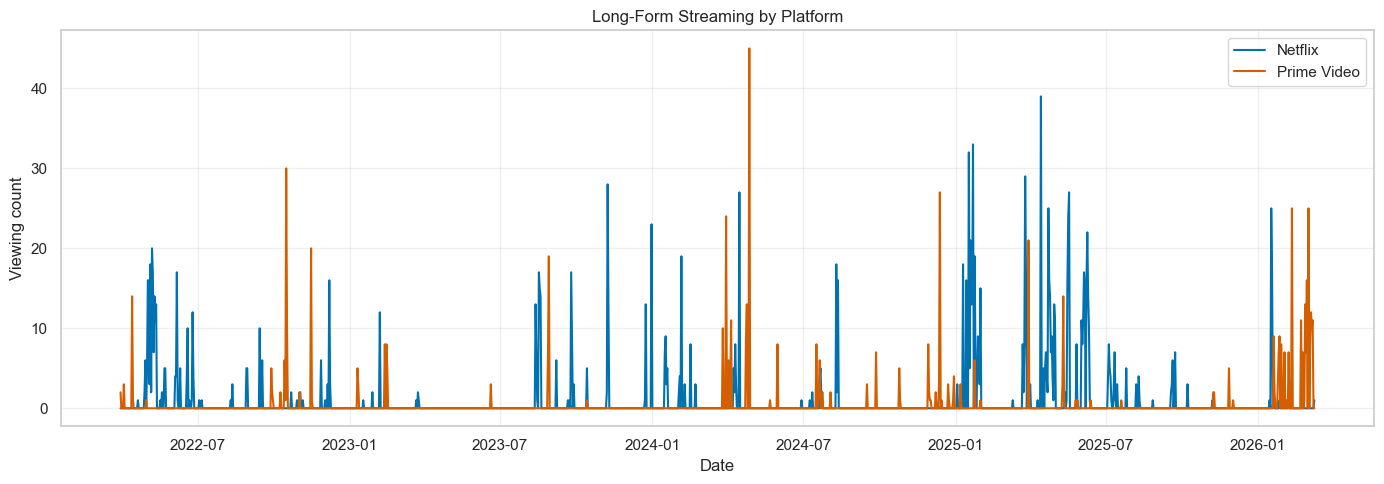

In [53]:
# Netflix and Prime Video comparison after filling non-active dates with 0.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(long_form_daily["fine_date"], long_form_daily["netflix_daily_count"], label="Netflix", color="#0072B2")
ax.plot(long_form_daily["fine_date"], long_form_daily["prime_daily_count"], label="Prime Video", color="#D55E00")

ax.set_title("Long-Form Streaming by Platform")
ax.set_xlabel("Date")
ax.set_ylabel("Viewing count")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "long_form_streaming_by_platform.png", dpi=300)
plt.show()


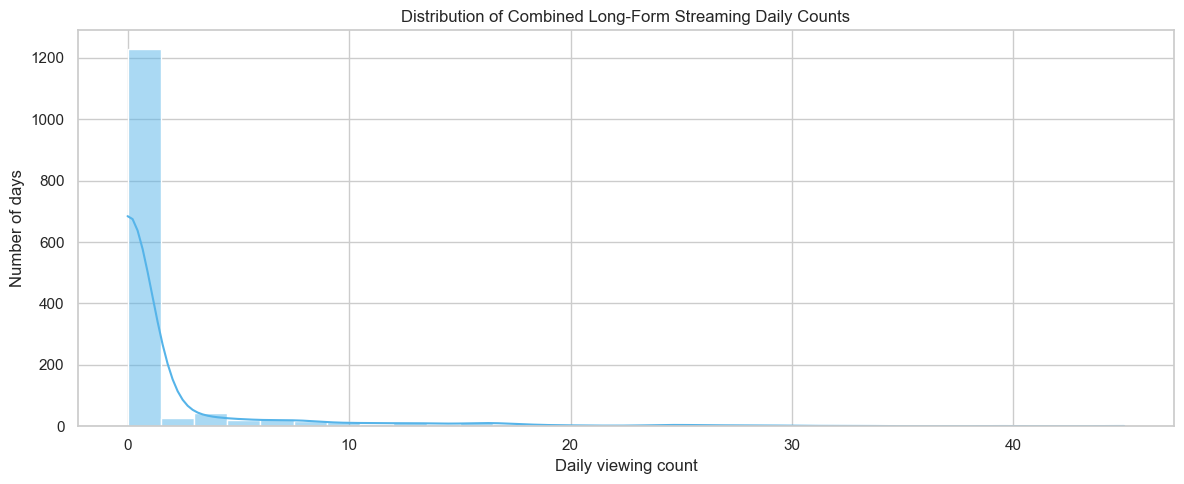

In [54]:
# Distribution of combined long-form streaming counts, including zero days.
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=long_form_daily,
    x="long_form_streaming_daily_count",
    bins=30,
    kde=True,
    ax=ax,
    color="#56B4E9"
)

ax.set_title("Distribution of Combined Long-Form Streaming Daily Counts")
ax.set_xlabel("Daily viewing count")
ax.set_ylabel("Number of days")
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "combined_long_form_distribution.png", dpi=300)
plt.show()


In [55]:
# Monthly long-form streaming counts make the trend easier to read than daily spikes.
long_form_monthly = long_form_daily.copy()
long_form_monthly["month"] = long_form_monthly["fine_date"].dt.to_period("M").dt.to_timestamp()

long_form_monthly = (
    long_form_monthly
    .groupby("month")[[
        "netflix_daily_count",
        "prime_daily_count",
        "long_form_streaming_daily_count"
    ]]
    .sum()
    .reset_index()
)

print("Monthly long-form streaming sample:")
print(long_form_monthly.head())


Monthly long-form streaming sample:
       month  netflix_daily_count  prime_daily_count  \
0 2022-03-01                    0                  2   
1 2022-04-01                    9                 19   
2 2022-05-01                  155                  0   
3 2022-06-01                   63                  0   
4 2022-07-01                    2                  0   

   long_form_streaming_daily_count  
0                                2  
1                               28  
2                              155  
3                               63  
4                                2  


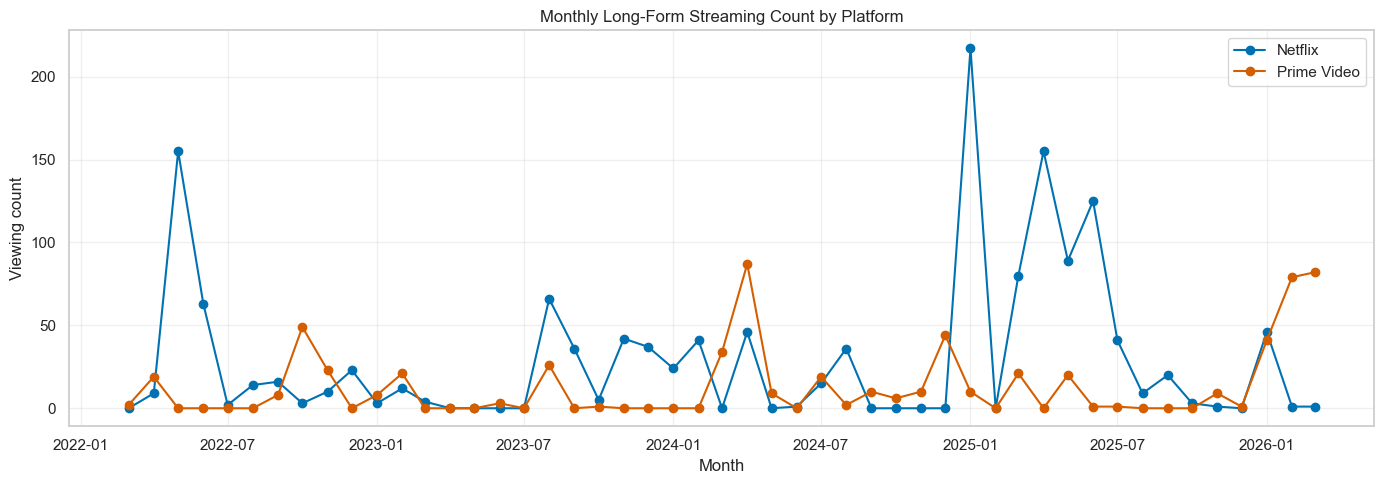

In [56]:
# Plot monthly Netflix and Prime Video viewing counts.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(long_form_monthly["month"], long_form_monthly["netflix_daily_count"], label="Netflix", color="#0072B2", marker="o")
ax.plot(long_form_monthly["month"], long_form_monthly["prime_daily_count"], label="Prime Video", color="#D55E00", marker="o")

ax.set_title("Monthly Long-Form Streaming Count by Platform")
ax.set_xlabel("Month")
ax.set_ylabel("Viewing count")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "monthly_long_form_count_by_platform.png", dpi=300)
plt.show()


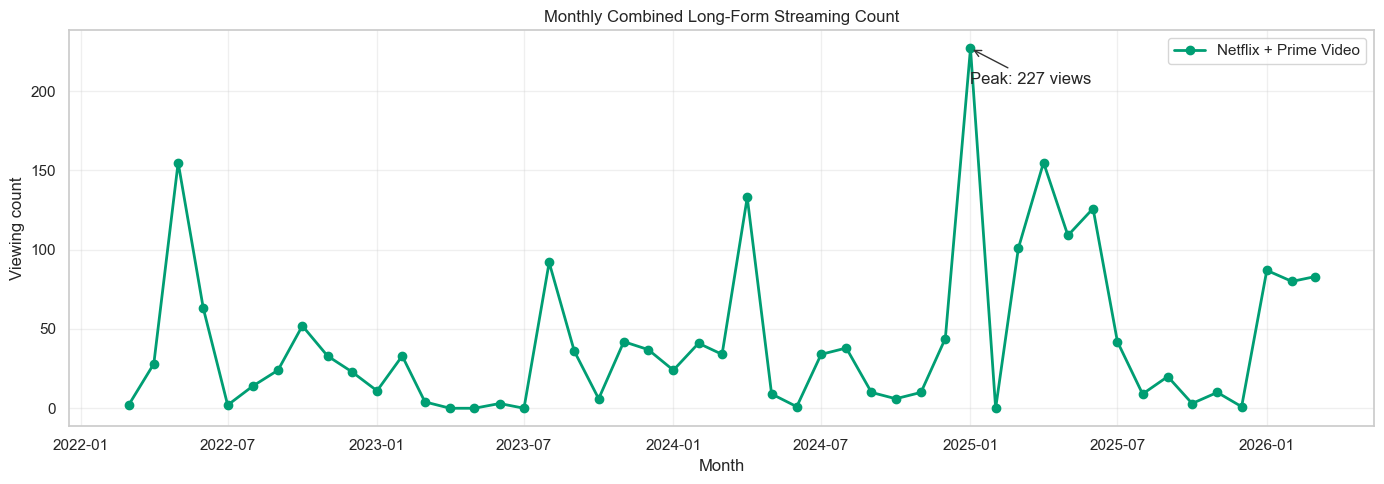

In [57]:
# Plot monthly combined long-form streaming count with peak annotation.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    long_form_monthly["month"],
    long_form_monthly["long_form_streaming_daily_count"],
    color="#009E73",
    marker="o",
    linewidth=2,
    label="Netflix + Prime Video"
)

max_idx = long_form_monthly["long_form_streaming_daily_count"].idxmax()
ax.annotate(
    f"Peak: {long_form_monthly.loc[max_idx, 'long_form_streaming_daily_count']} views",
    xy=(long_form_monthly.loc[max_idx, "month"], long_form_monthly.loc[max_idx, "long_form_streaming_daily_count"]),
    xytext=(long_form_monthly.loc[max_idx, "month"], long_form_monthly["long_form_streaming_daily_count"].max() * 0.9),
    arrowprops=dict(arrowstyle="->", color="#333333")
)

ax.set_title("Monthly Combined Long-Form Streaming Count")
ax.set_xlabel("Month")
ax.set_ylabel("Viewing count")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "monthly_combined_long_form_count.png", dpi=300)
plt.show()


**Richer Daily Pattern Checks**

These plots add the same kind of variety used in the recitation examples: box plots, scatter plots, and a multi-panel summary.


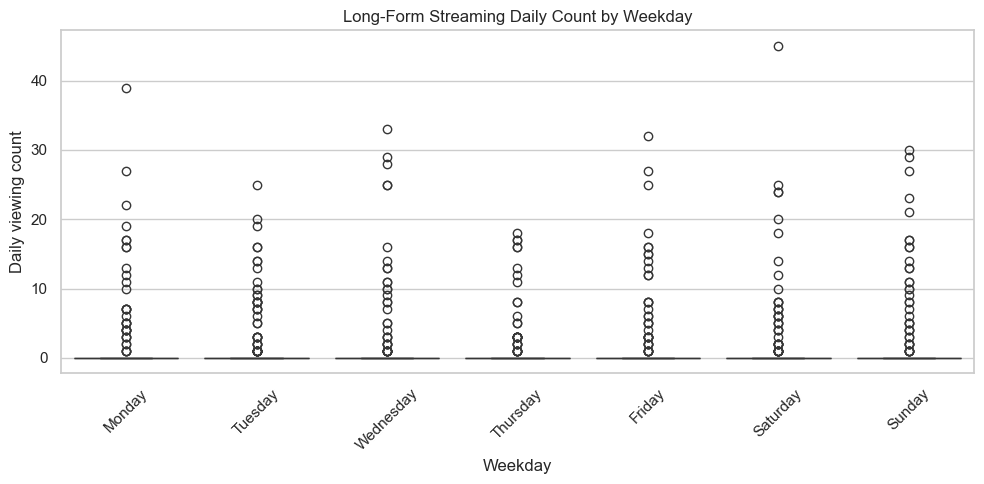

In [58]:
# Weekday pattern for combined long-form streaming.
long_form_daily["weekday"] = long_form_daily["fine_date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=long_form_daily,
    x="weekday",
    y="long_form_streaming_daily_count",
    order=weekday_order,
    ax=ax
)

ax.set_title("Long-Form Streaming Daily Count by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Daily viewing count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "long_form_daily_count_by_weekday_boxplot.png", dpi=300)
plt.show()


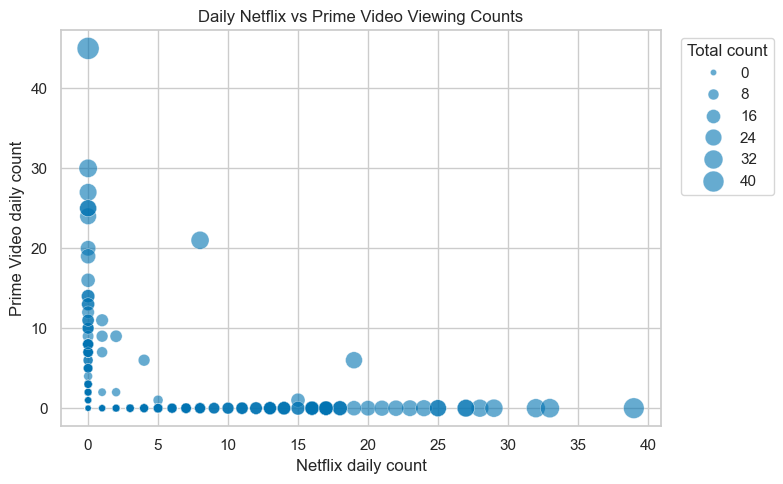

In [59]:
# Relationship between daily Netflix and Prime Video activity.
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=long_form_daily,
    x="netflix_daily_count",
    y="prime_daily_count",
    size="long_form_streaming_daily_count",
    sizes=(20, 250),
    alpha=0.6,
    ax=ax
)

ax.set_title("Daily Netflix vs Prime Video Viewing Counts")
ax.set_xlabel("Netflix daily count")
ax.set_ylabel("Prime Video daily count")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Total count")
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "netflix_vs_prime_daily_scatter.png", dpi=300)
plt.show()


In [60]:
# Prime Video record type split.
# Netflix does not have a record_type column, so this split is only possible for Prime Video.
prime_record_type_counts = (
    prime_data["record_type"]
    .value_counts()
    .reset_index()
)

prime_record_type_counts.columns = ["record_type", "watch_count"]

print("Prime Video record type counts:")
print(prime_record_type_counts)


Prime Video record type counts:
  record_type  watch_count
0     episode          667
1       movie           52


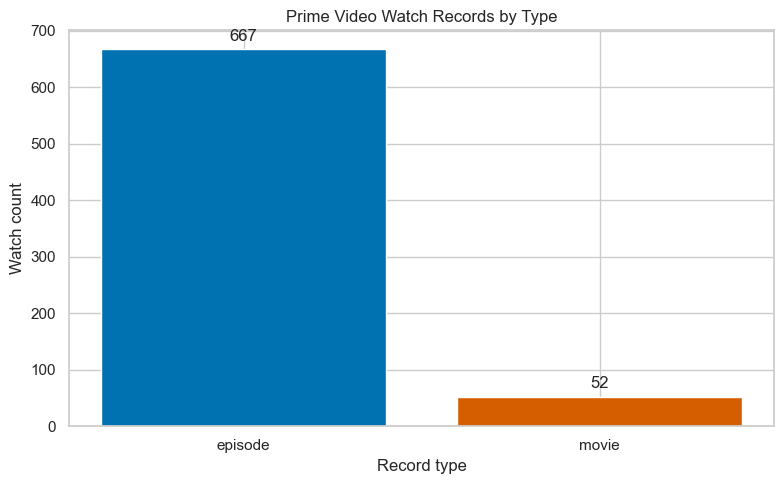

In [61]:
# Plot Prime Video episode/movie split.
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(prime_record_type_counts["record_type"], prime_record_type_counts["watch_count"], color=["#0072B2", "#D55E00"])

ax.set_title("Prime Video Watch Records by Type")
ax.set_xlabel("Record type")
ax.set_ylabel("Watch count")
ax.bar_label(bars, padding=4)
plt.tight_layout()

plt.savefig(prime_netflix_image_dir / "prime_video_record_type_split.png", dpi=300)
plt.show()


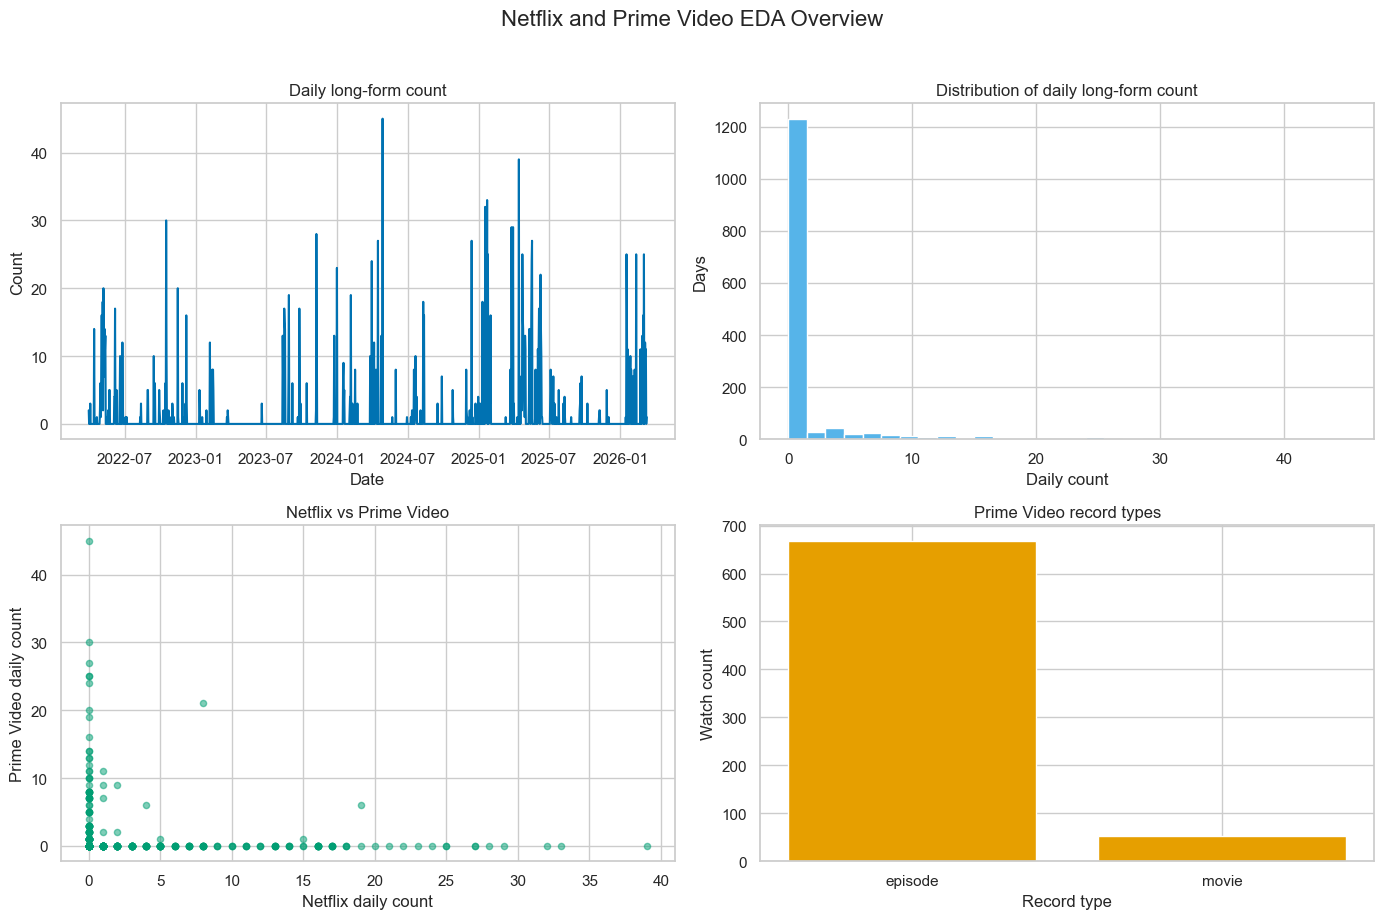

In [62]:
# 2x2 overview plot, similar to the recitation multi-panel style.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

axes[0].plot(long_form_daily["fine_date"], long_form_daily["long_form_streaming_daily_count"], color="#0072B2")
axes[0].set_title("Daily long-form count")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")

axes[1].hist(long_form_daily["long_form_streaming_daily_count"], bins=30, color="#56B4E9", edgecolor="white")
axes[1].set_title("Distribution of daily long-form count")
axes[1].set_xlabel("Daily count")
axes[1].set_ylabel("Days")

axes[2].scatter(
    long_form_daily["netflix_daily_count"],
    long_form_daily["prime_daily_count"],
    alpha=0.5,
    s=20,
    color="#009E73"
)
axes[2].set_title("Netflix vs Prime Video")
axes[2].set_xlabel("Netflix daily count")
axes[2].set_ylabel("Prime Video daily count")

axes[3].bar(prime_record_type_counts["record_type"], prime_record_type_counts["watch_count"], color="#E69F00")
axes[3].set_title("Prime Video record types")
axes[3].set_xlabel("Record type")
axes[3].set_ylabel("Watch count")

fig.suptitle("Netflix and Prime Video EDA Overview", fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig(prime_netflix_image_dir / "prime_netflix_eda_overview_panel.png", dpi=300)
plt.show()


**Final Notes**

The combined daily table is the most useful output for later cross-platform EDA. Netflix and Prime Video remain separate public datasets, but `long_form_streaming_daily_count` and `long_form_streaming_active_day` allow them to be analyzed together as long-form streaming.

Malformed Netflix titles are excluded only from title-ranking plots. They are still counted as viewing records in daily and combined activity variables.
